In [30]:
import os
import yaml
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

def plot_participant_metrics(participant_dir):
    """
    Reads TensorFlow event files and hparams.yaml from a directory,
    prints hyperparameters, and plots all scalar metrics.

    Args:
        participant_dir (str): The path to the participant's directory
                               (e.g., 'metrics/participant_0').
    """
    print(f"--- Processing directory: {participant_dir} ---")

    # --- 1. Read and print hyperparameters ---
    hparams_path = os.path.join(participant_dir, 'hparams.yaml')
    try:
        with open(hparams_path, 'r') as f:
            hparams = yaml.safe_load(f)
            print("Hyperparameters found:")
            print(yaml.dump(hparams, indent=2))
    except FileNotFoundError:
        print("hparams.yaml not found in this directory.")
    except Exception as e:
        print(f"Error reading hparams.yaml: {e}")

    # --- 2. Load data from .tfevents files ---
    # The EventAccumulator can gracefully handle multiple event files in one directory.
    try:
        ea = event_accumulator.EventAccumulator(
            participant_dir,
            size_guidance={event_accumulator.SCALARS: 0} # Load all scalars
        )
        ea.Reload() # Load all events from disk
    except Exception as e:
        print(f"Error loading event files: {e}")
        print("Please ensure TensorFlow is installed ('pip install tensorflow').")
        return

    scalar_tags = ea.Tags()['scalars']
    if not scalar_tags:
        print("No scalar metrics found in the event files.")
        return

    print(f"\nFound scalar tags: {scalar_tags}")

    # --- 3. Plot each scalar metric ---
    for tag in scalar_tags:
        # Extract events
        events = ea.Scalars(tag)
        steps = [event.step for event in events]
        values = [event.value for event in events]

        # Create a new plot for each tag
        plt.figure(figsize=(10, 6))
        plt.plot(steps, values, label=tag)
        plt.title(f'Metric: {tag}')
        plt.xlabel('Step')
        plt.ylabel('Value')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

    # Show all the plots
    print("\nDisplaying plots...")
    plt.show()
    print("--- Finished processing. ---")



--- Processing directory: app/logs/nebula_DFL_2025_10_14_19_55_23/metrics/participant_0 ---
Hyperparameters found:
{}


Found scalar tags: ['W-CPU/CPU global (%)', 'W-CPU/CPU process (%)', 'W-CPU/CPU temperature (°)', 'Z-RAM/RAM global (%)', 'Z-RAM/RAM global (MB)', 'Z-RAM/RAM process (%)', 'Z-RAM/RAM process (MB)', 'Y-Disk/Disk (%)', 'X-Network/Network (MB sent)', 'X-Network/Network (MB received)', 'X-Network/Network (packets sent)', 'X-Network/Network (packets received)', 'X-Network/Connections', 'A-Round', 'Test (Local)/Accuracy', 'Test (Local)/Precision', 'Test (Local)/Recall', 'Test (Local)/F1Score', 'Test (Global)/Accuracy', 'Test (Global)/Precision', 'Test (Global)/Recall', 'Test (Global)/F1Score', 'val_loss/dataloader_idx_0', 'val_accuracy/dataloader_idx_0', 'Validation/Accuracy', 'Validation/Precision', 'Validation/Recall', 'Validation/F1Score', 'Train/Loss', 'Train/Accuracy', 'Train/Precision', 'Train/Recall', 'Train/F1Score']


/tmp/ipykernel_2825436/3645160555.py:57: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))



Displaying plots...


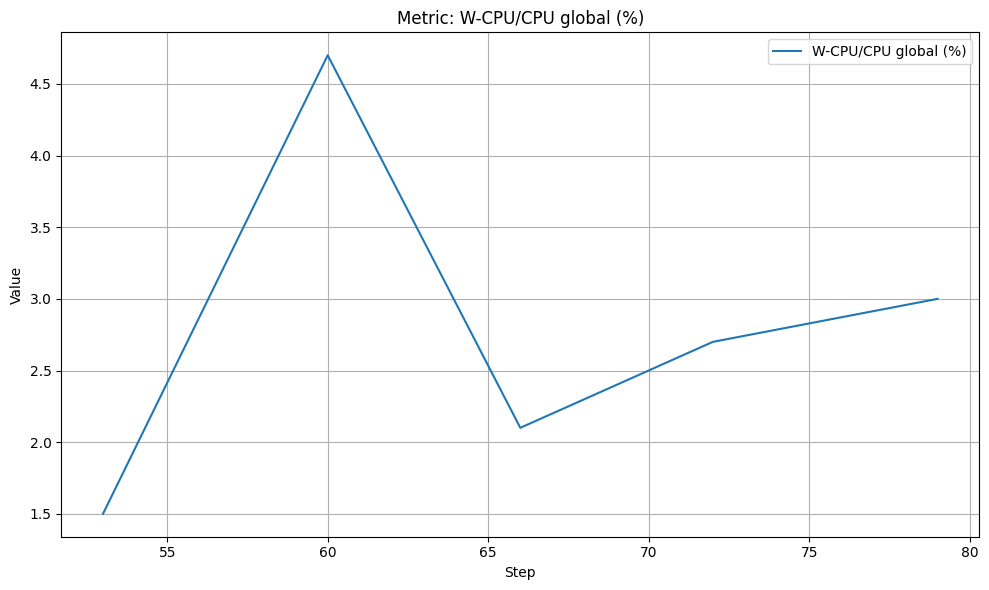

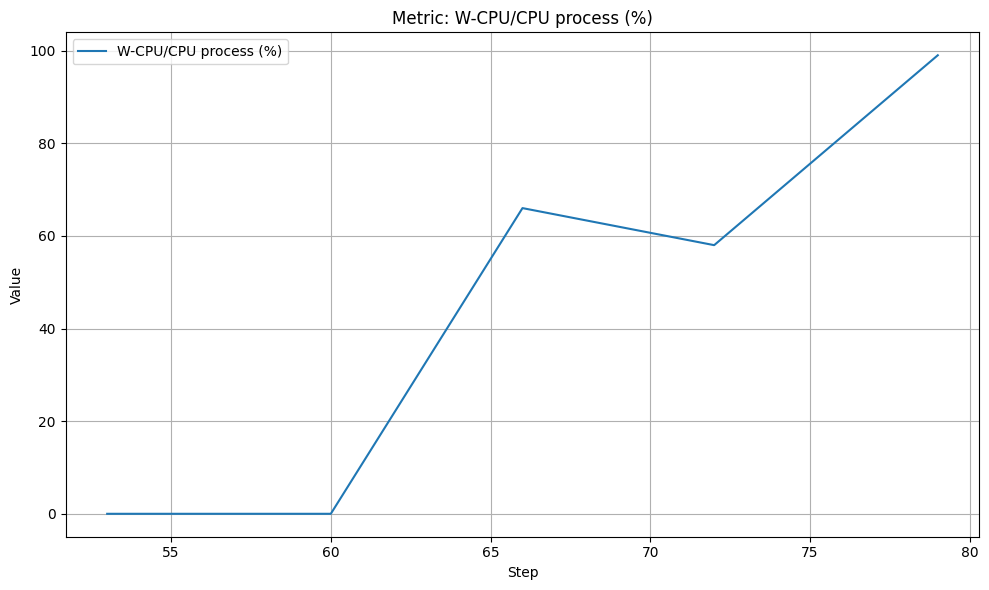

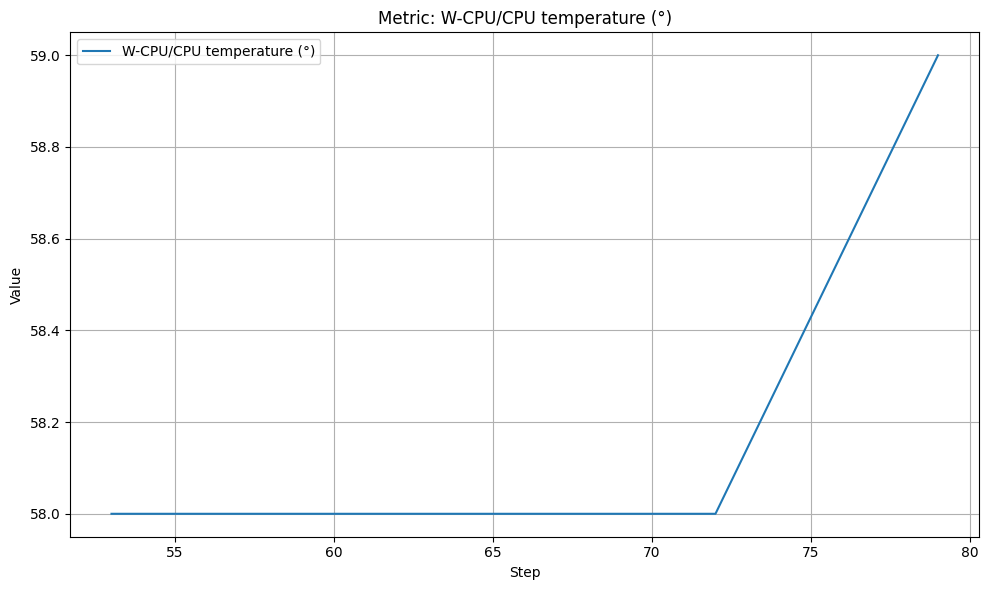

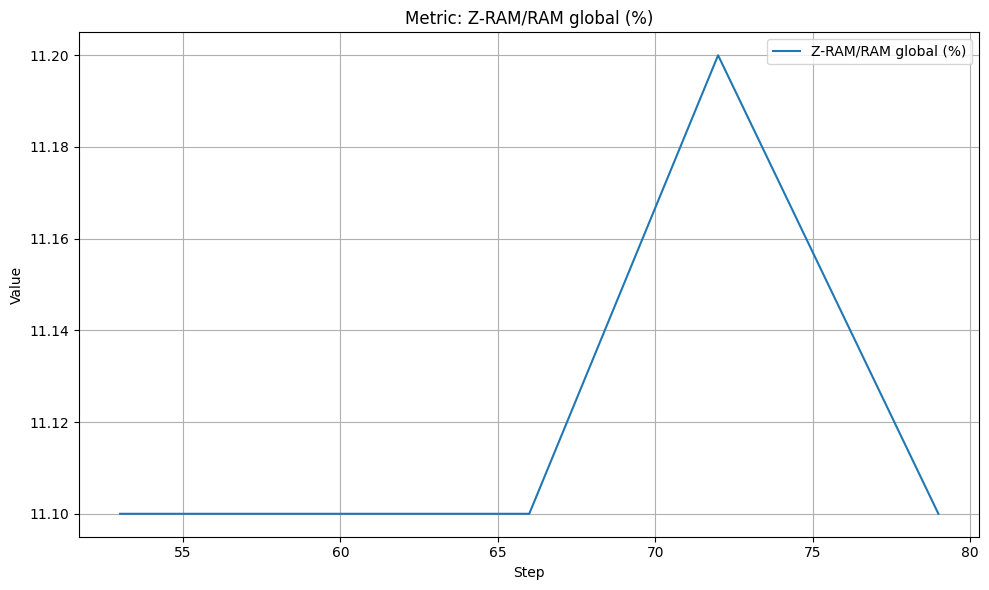

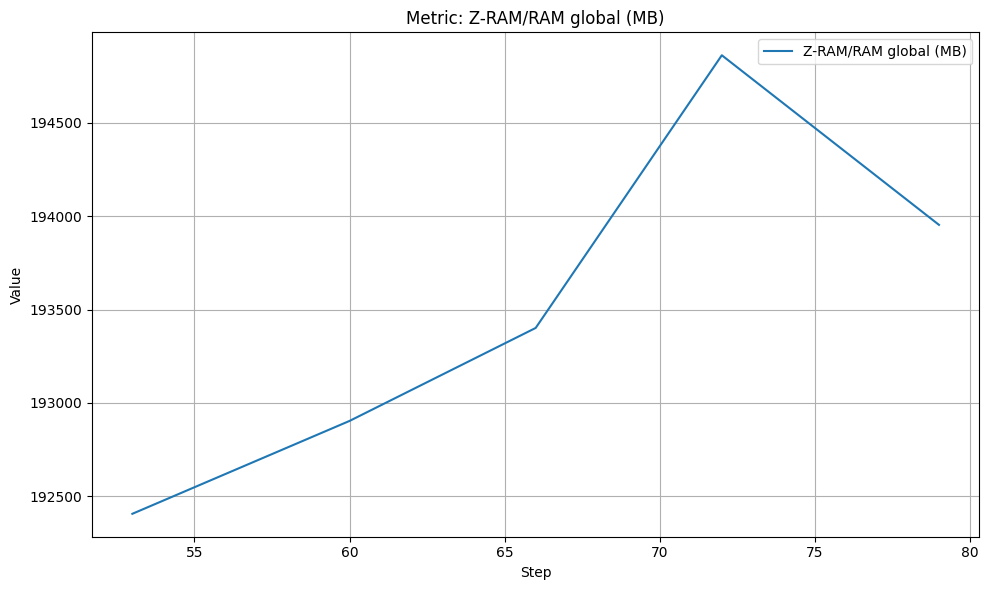

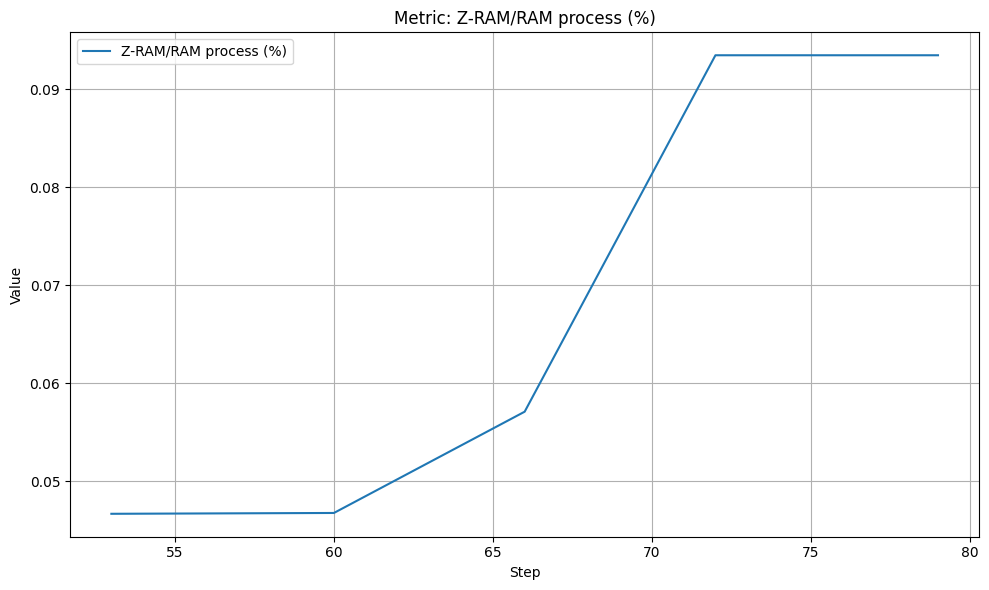

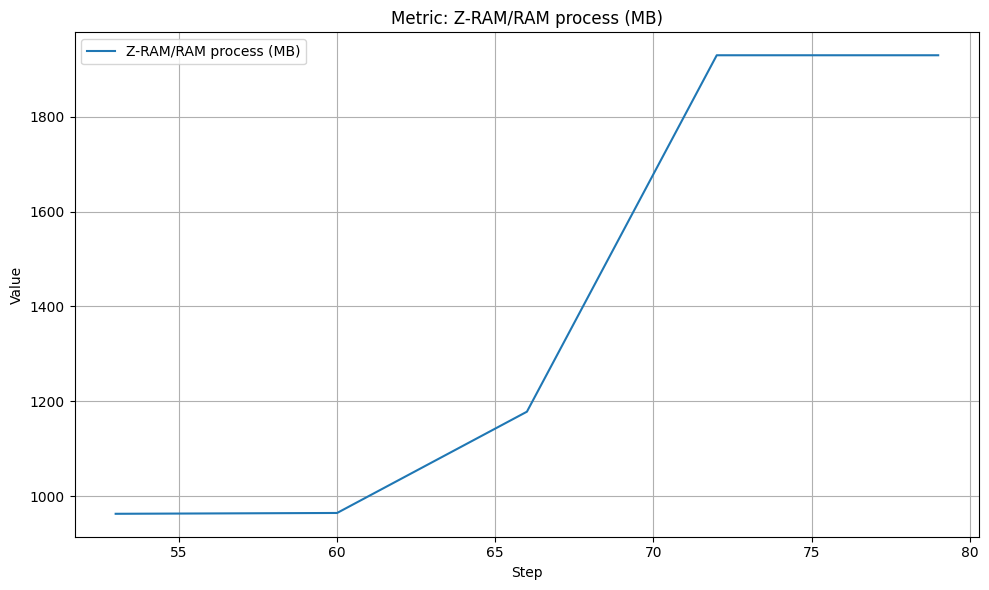

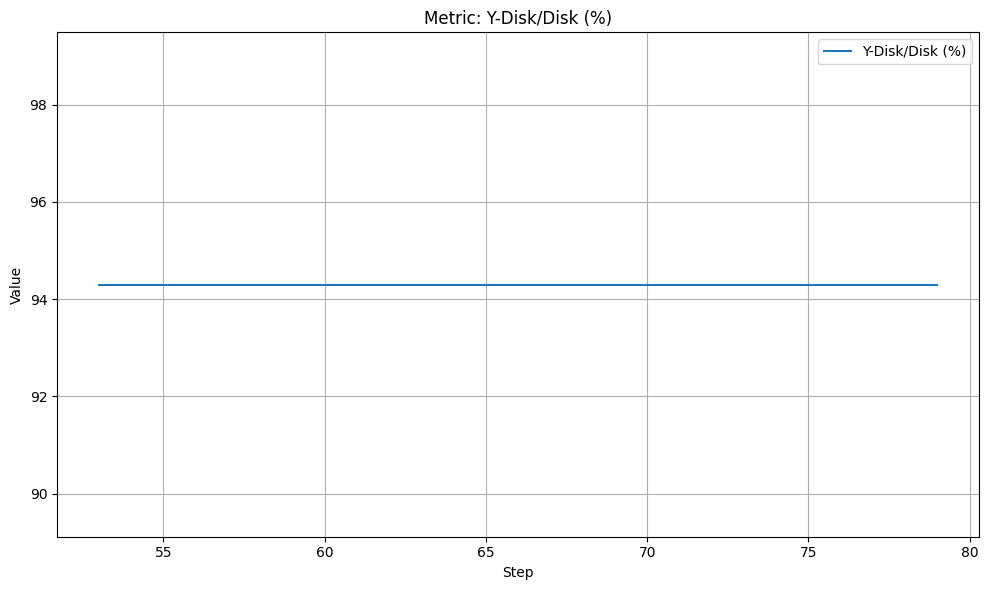

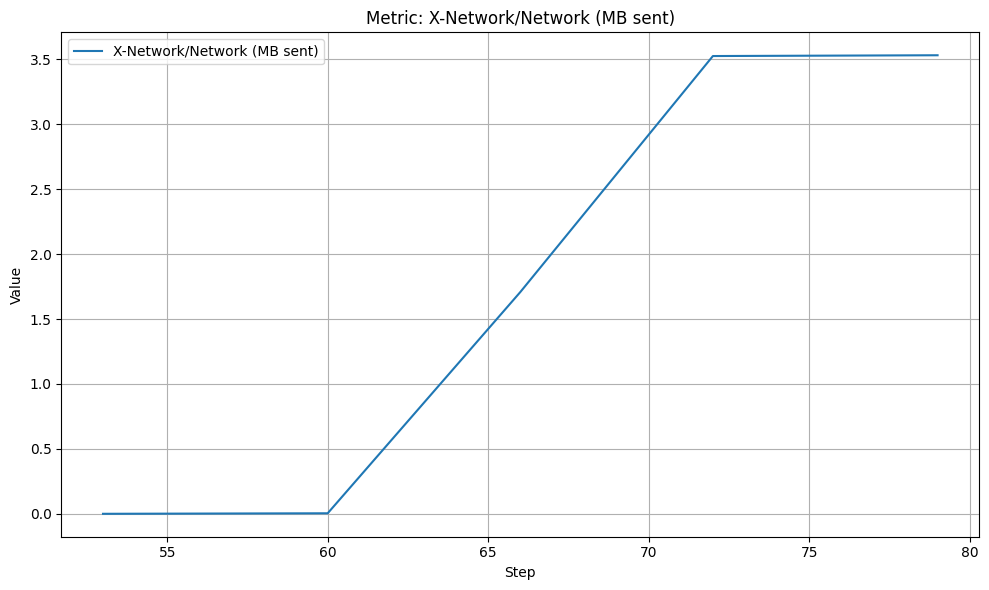

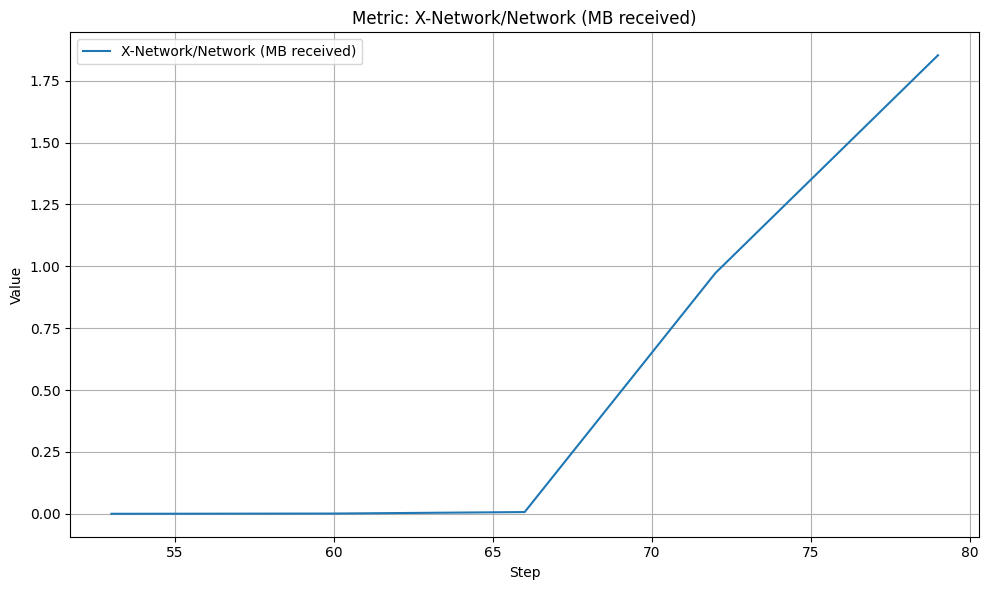

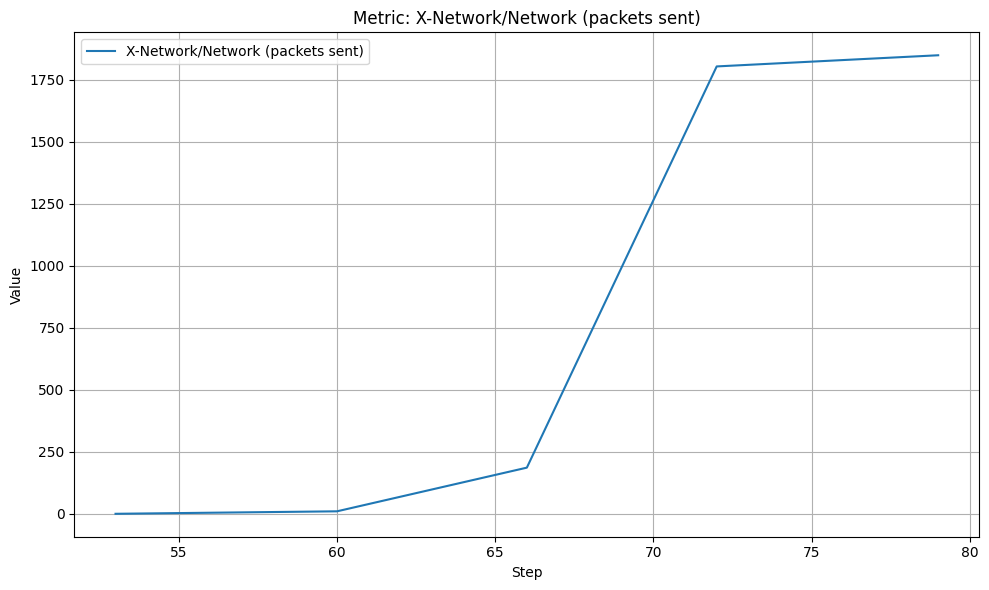

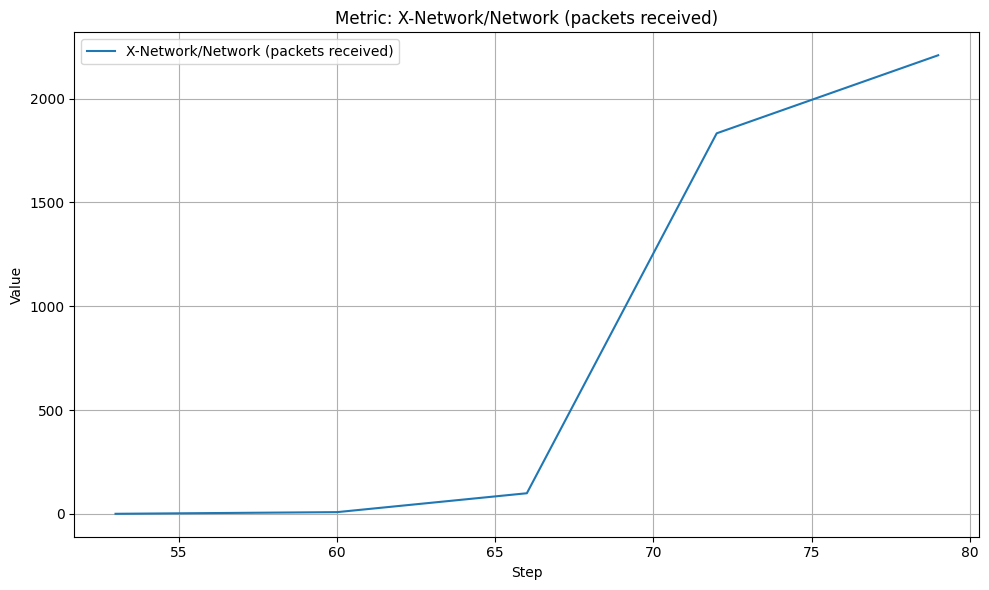

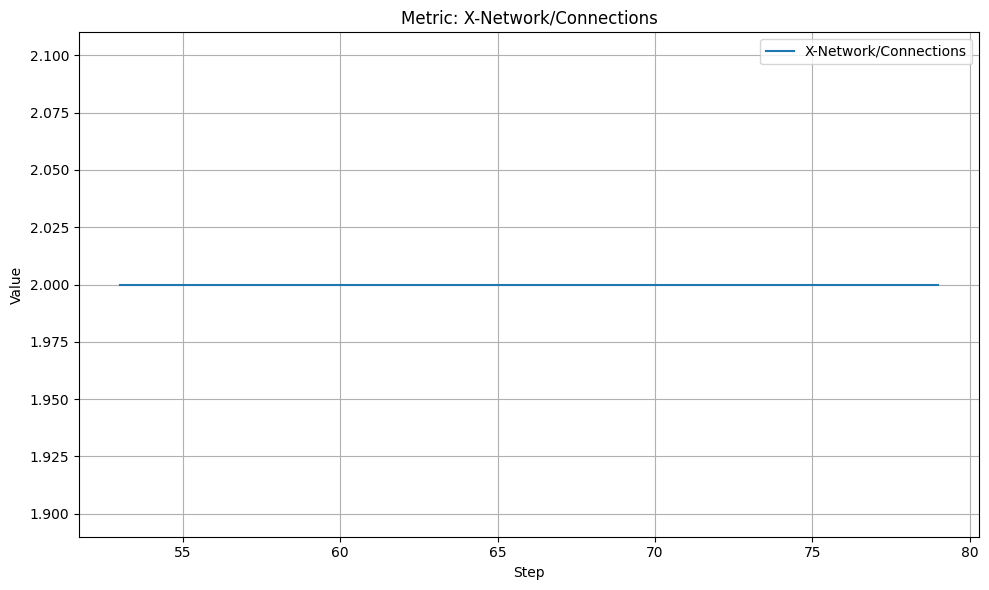

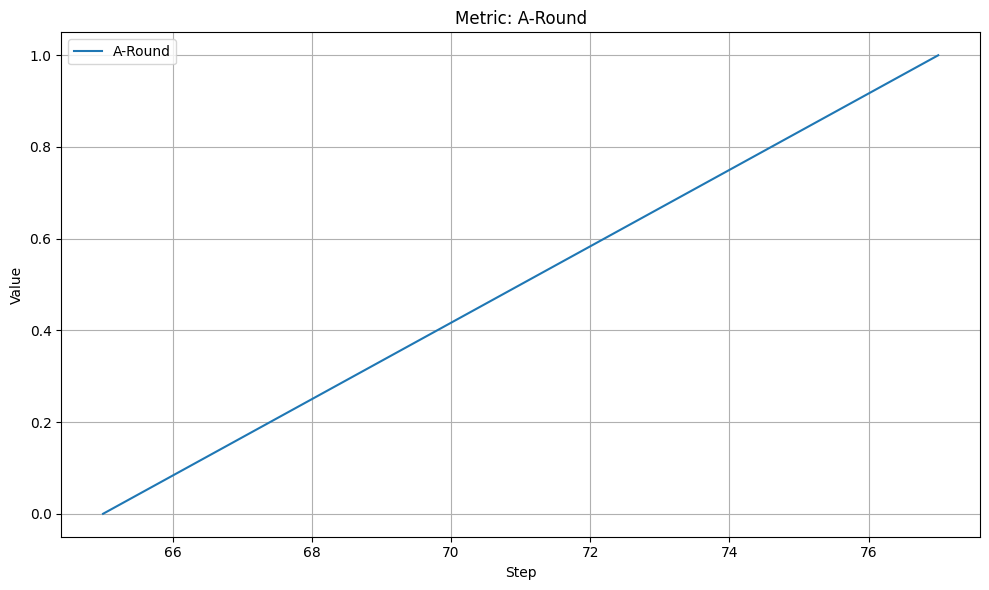

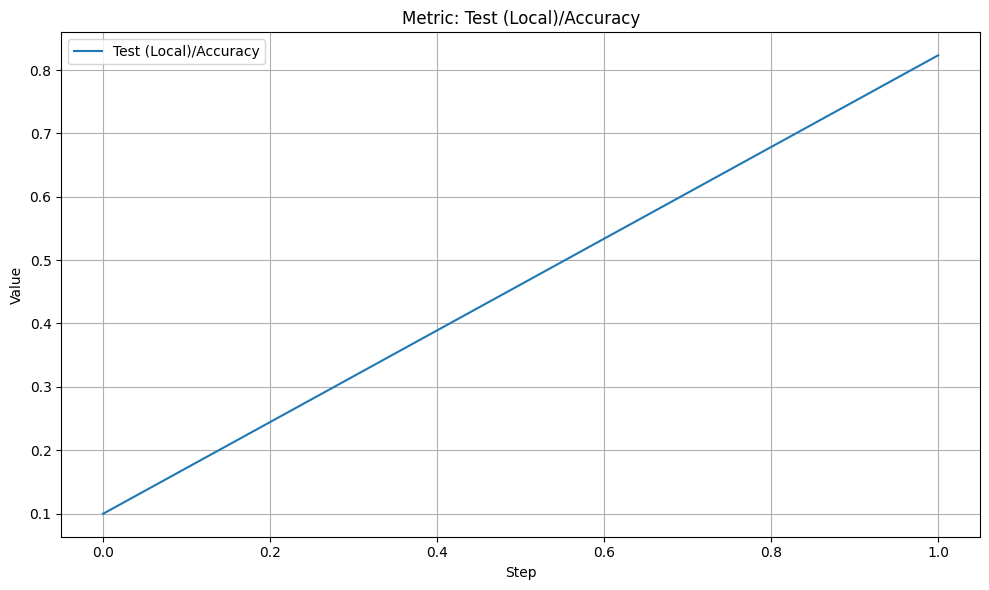

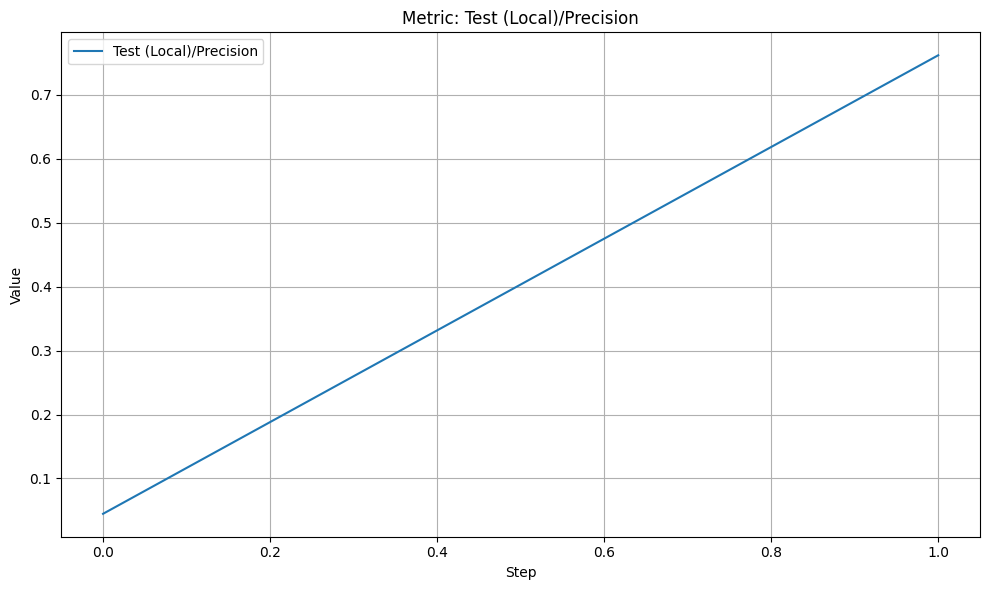

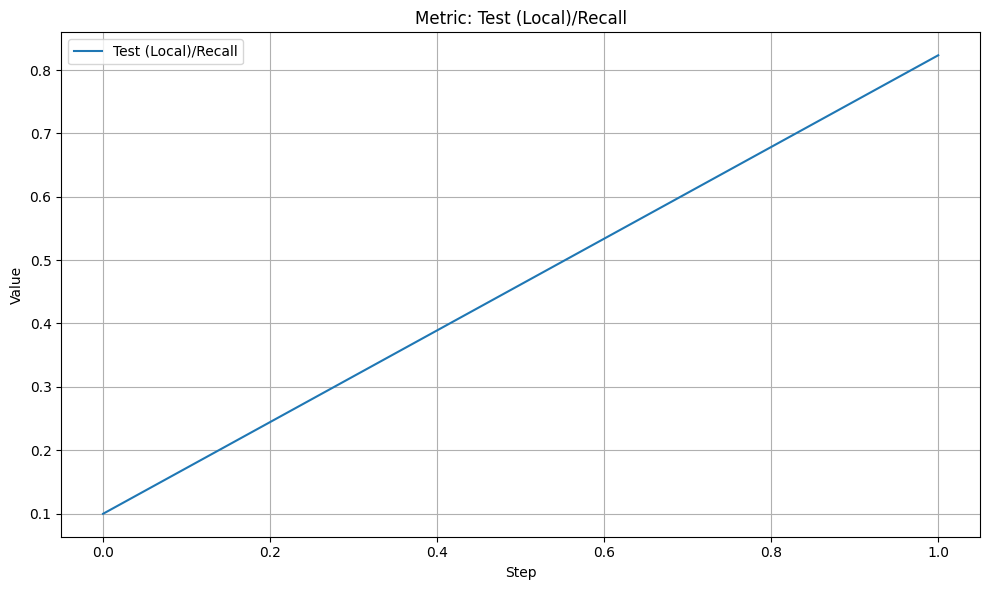

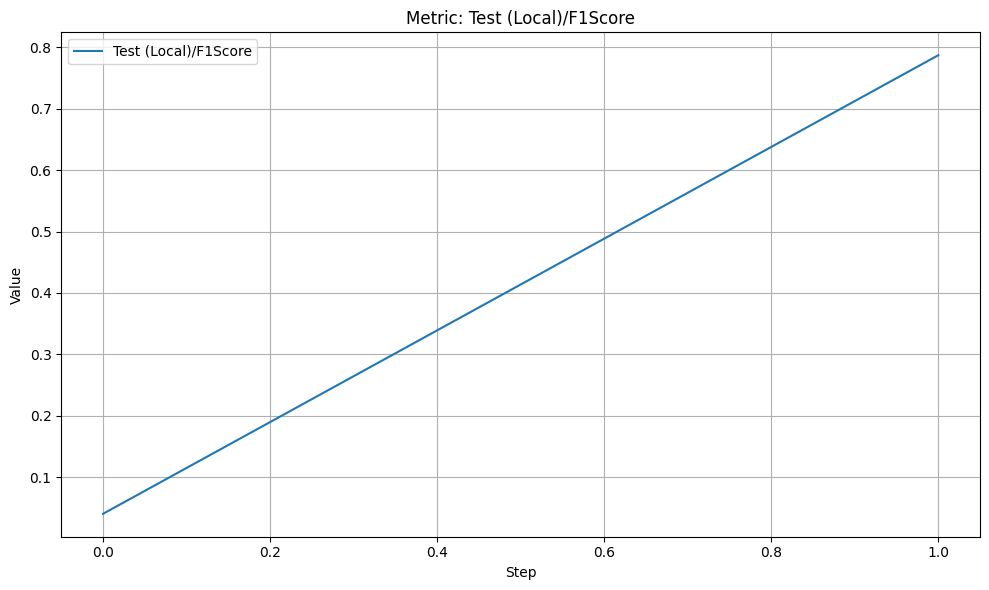

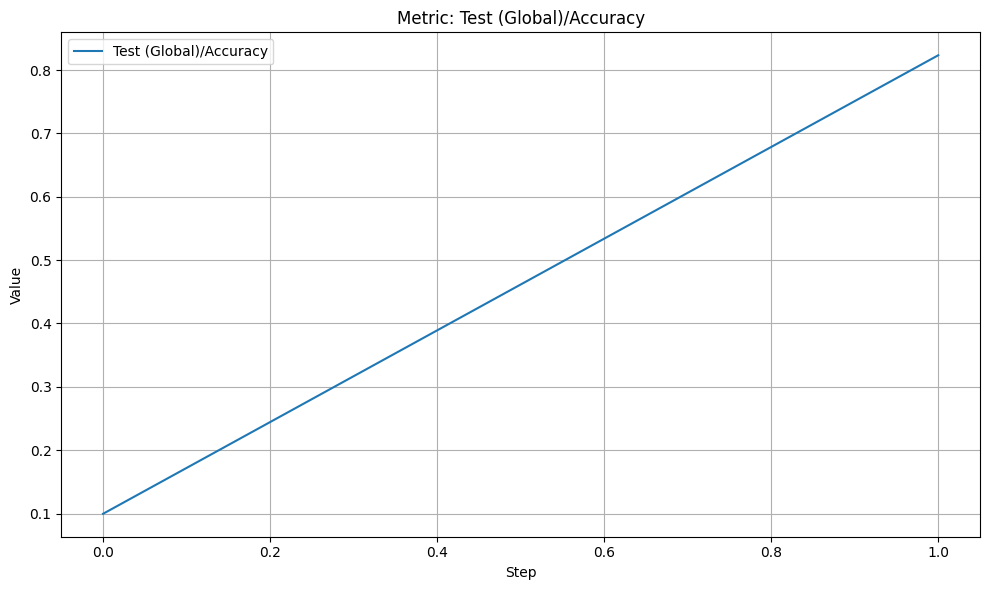

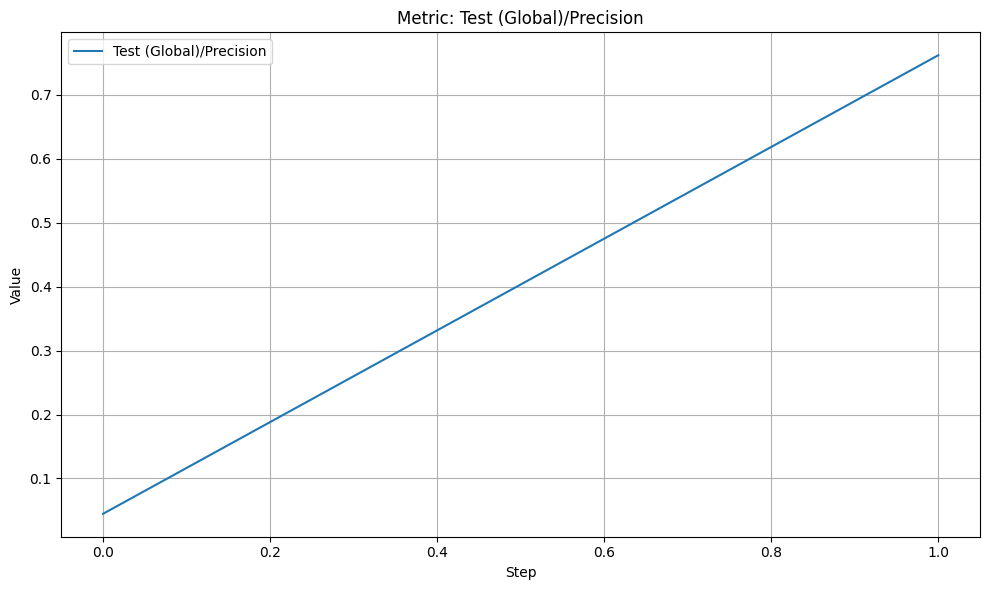

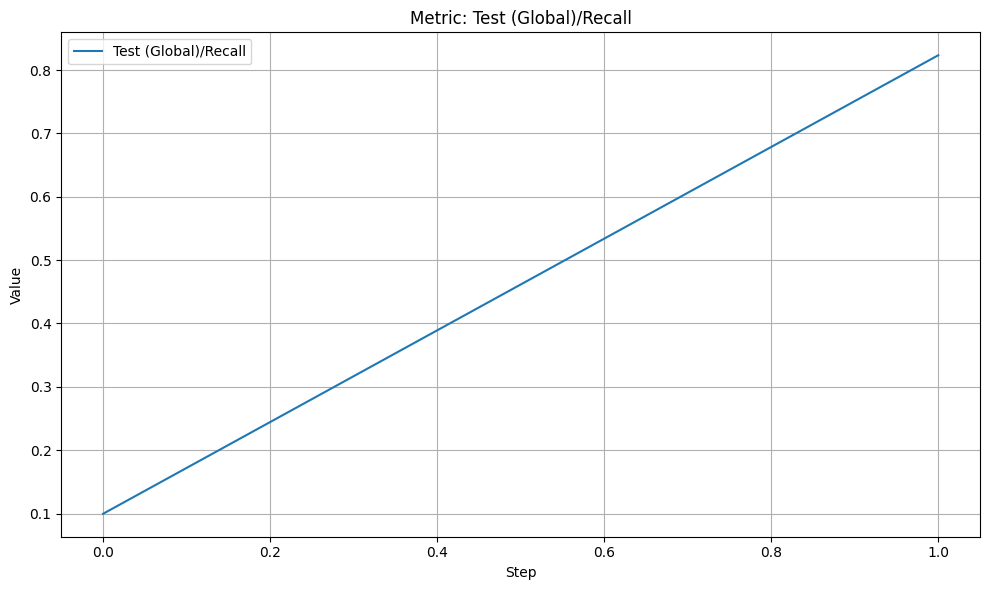

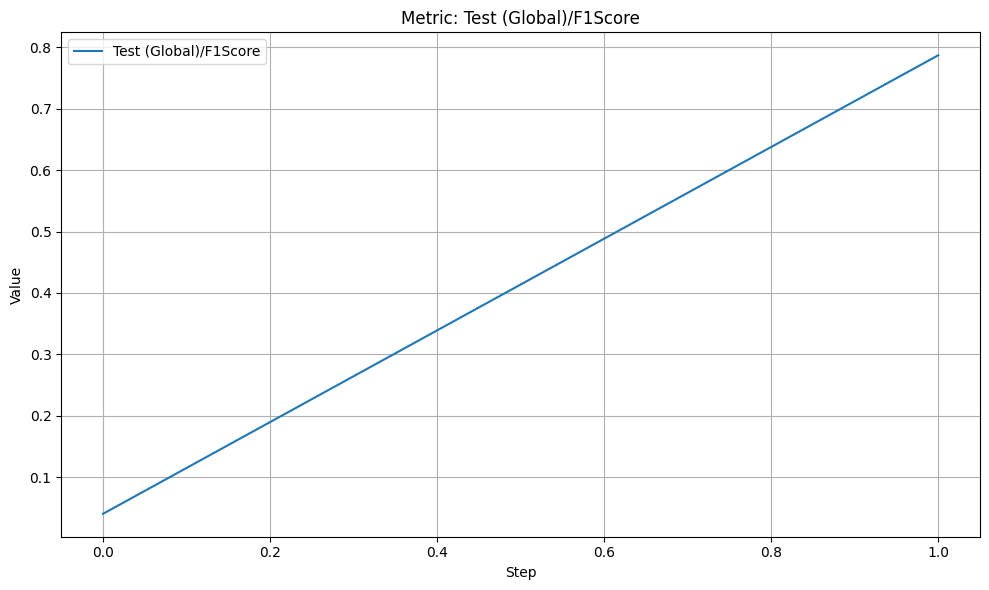

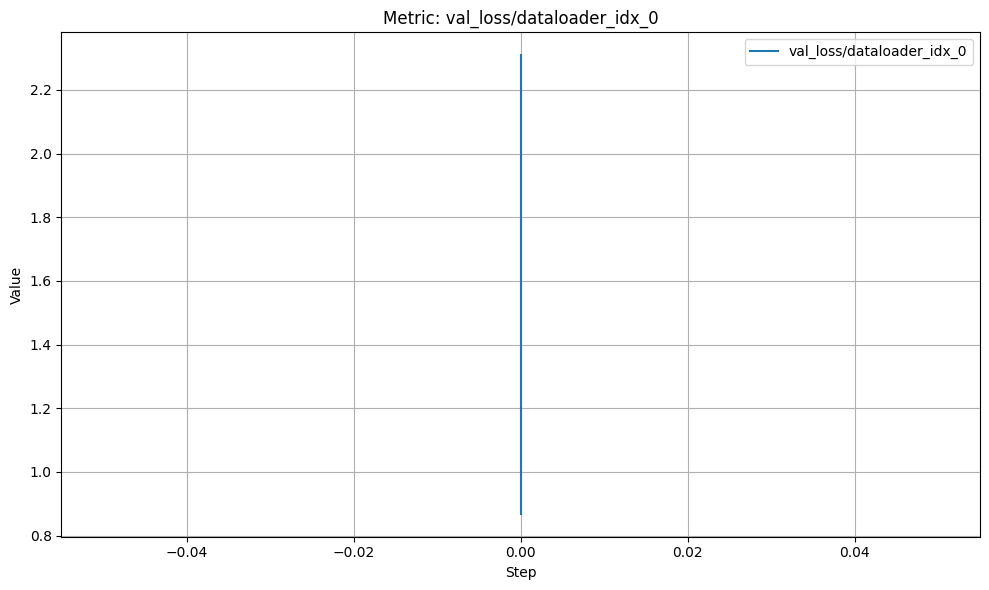

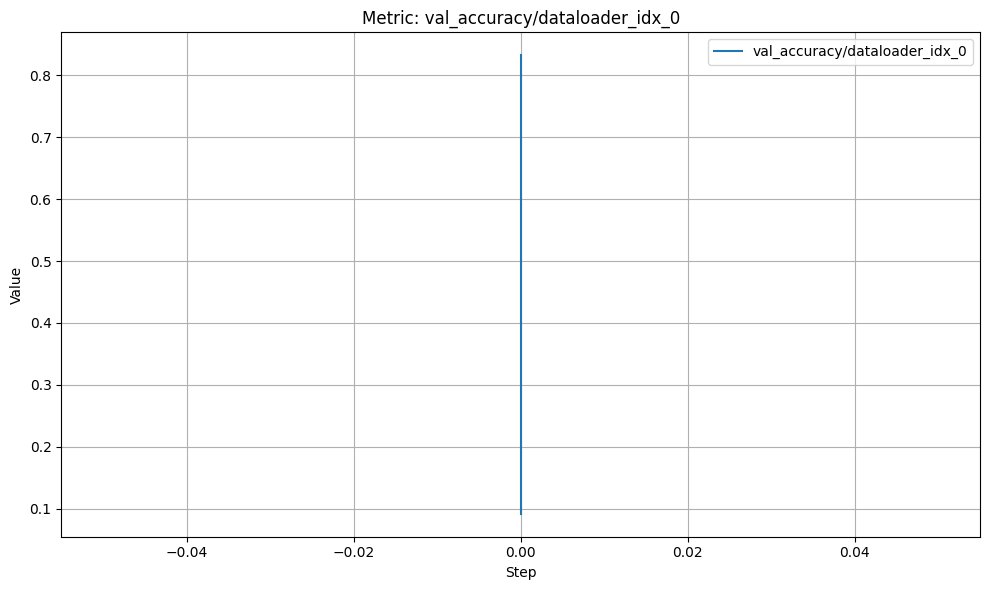

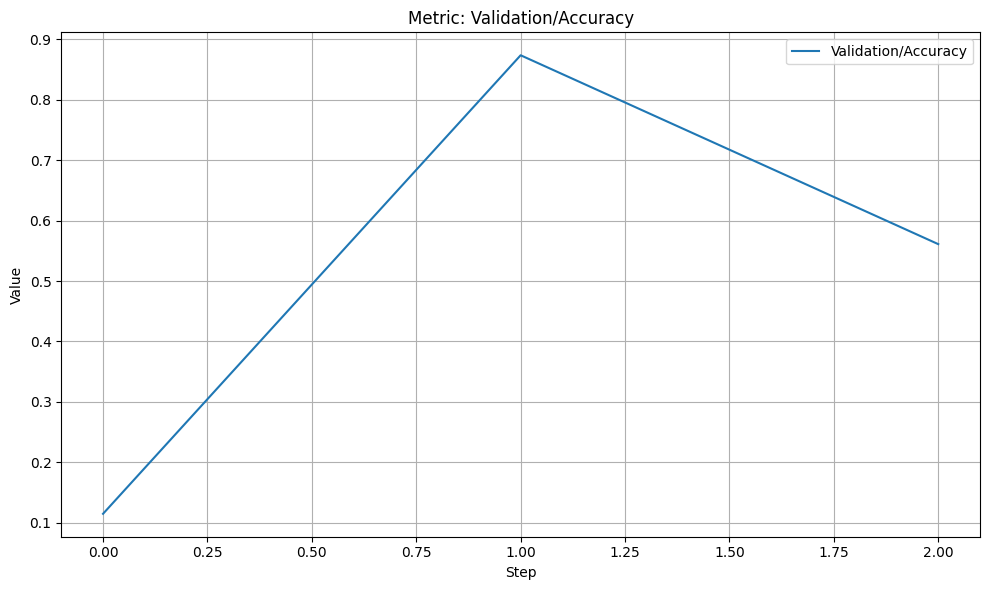

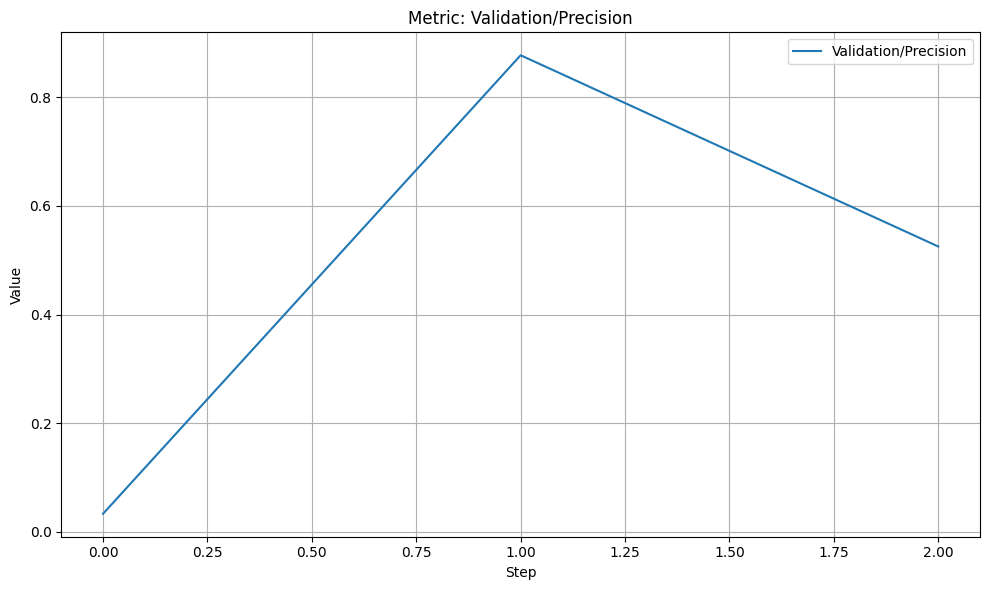

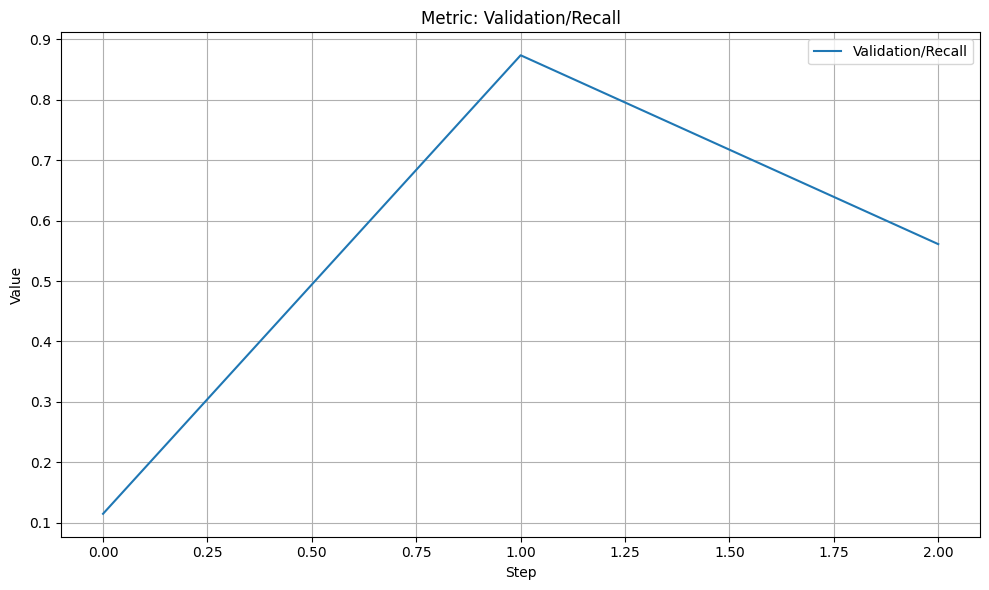

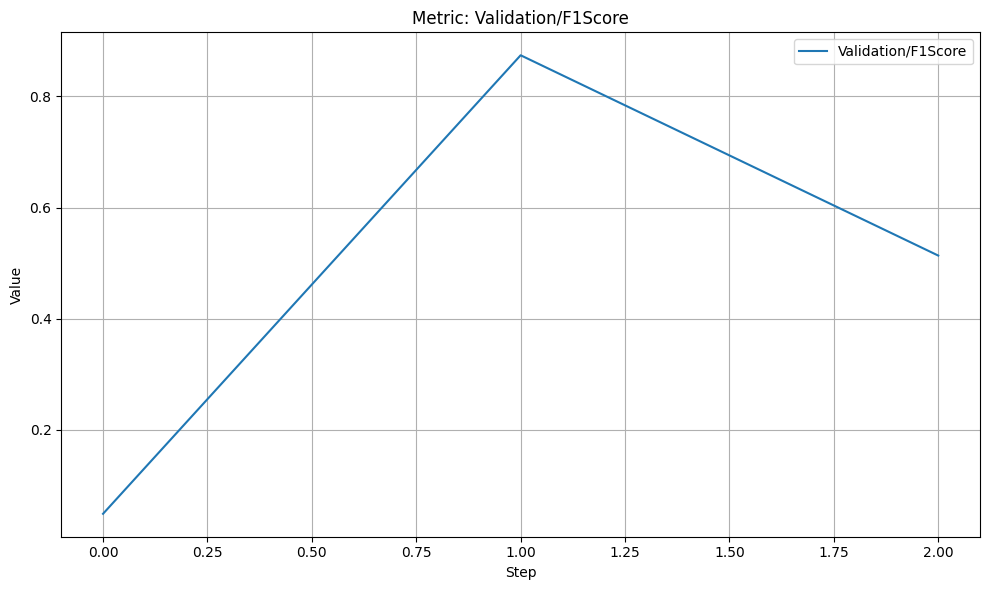

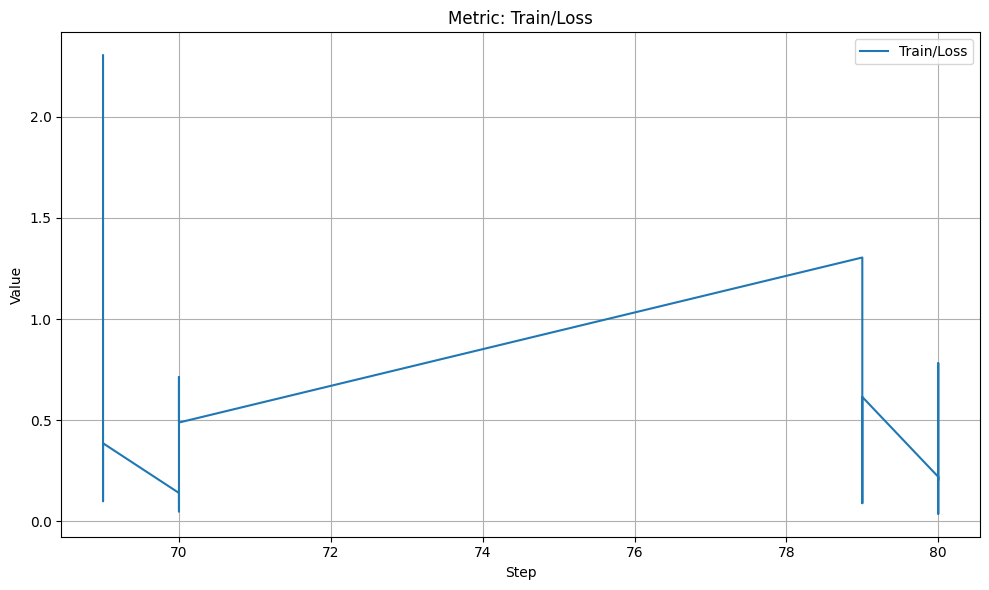

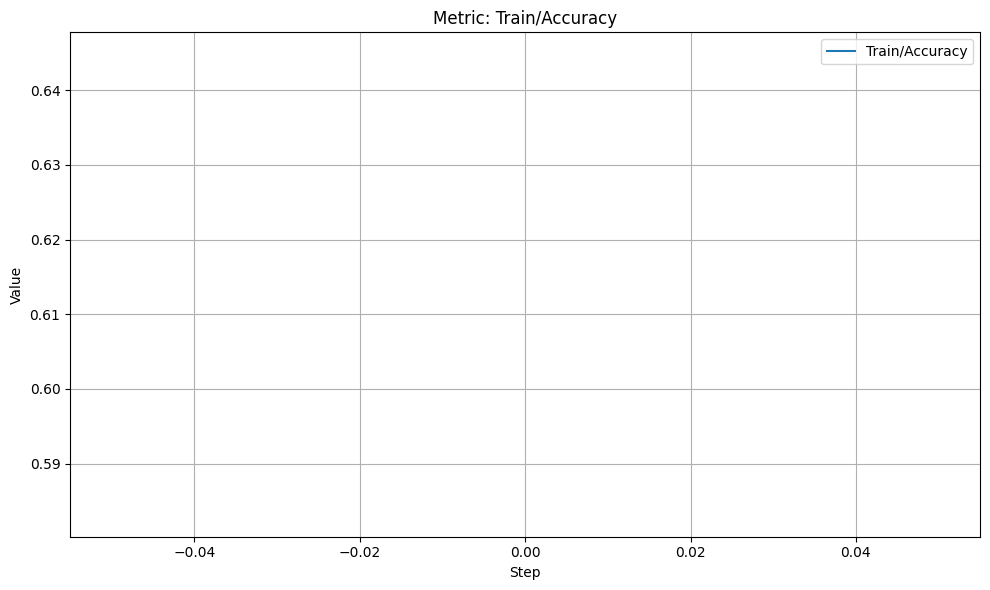

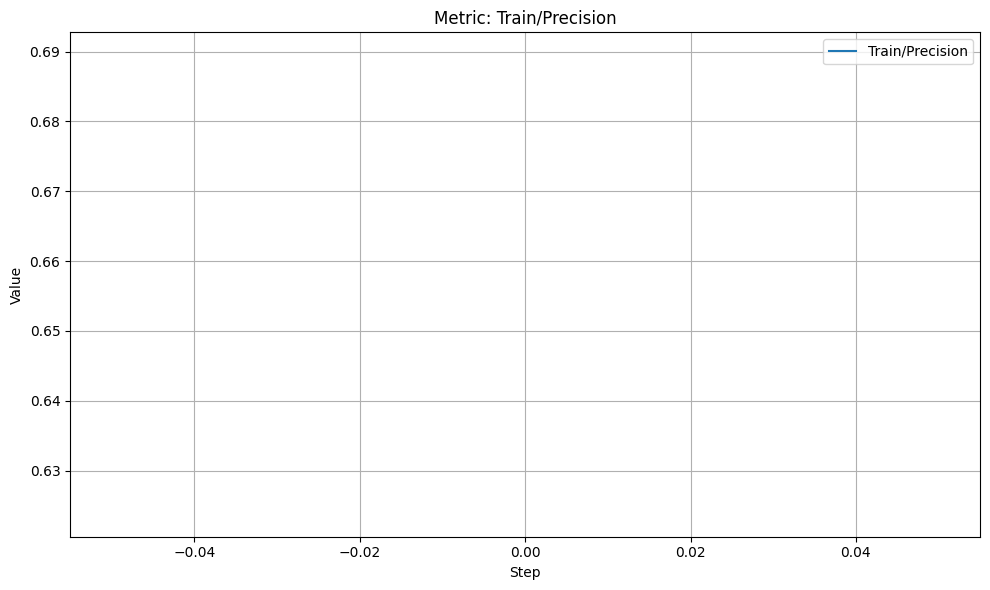

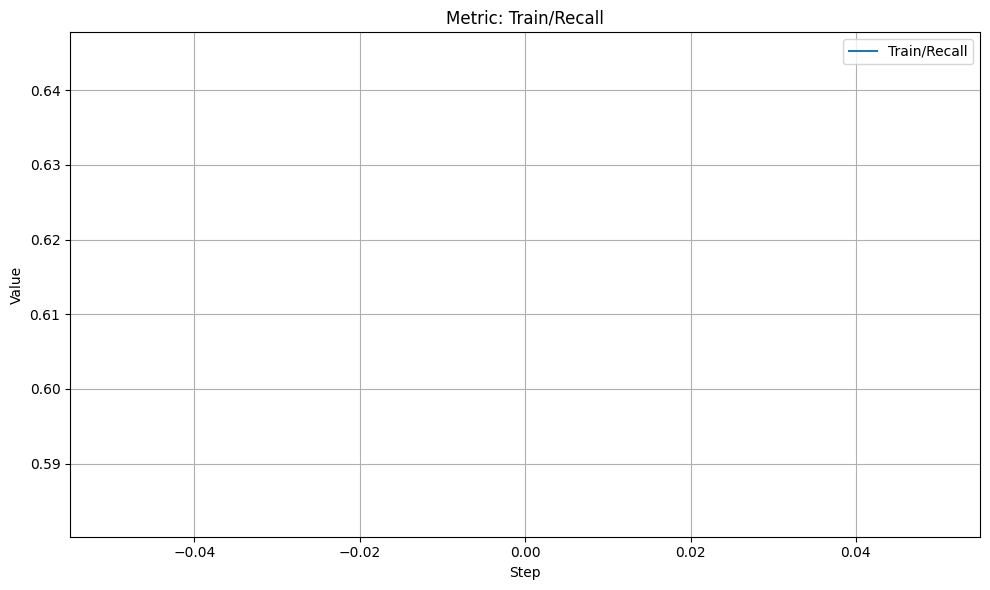

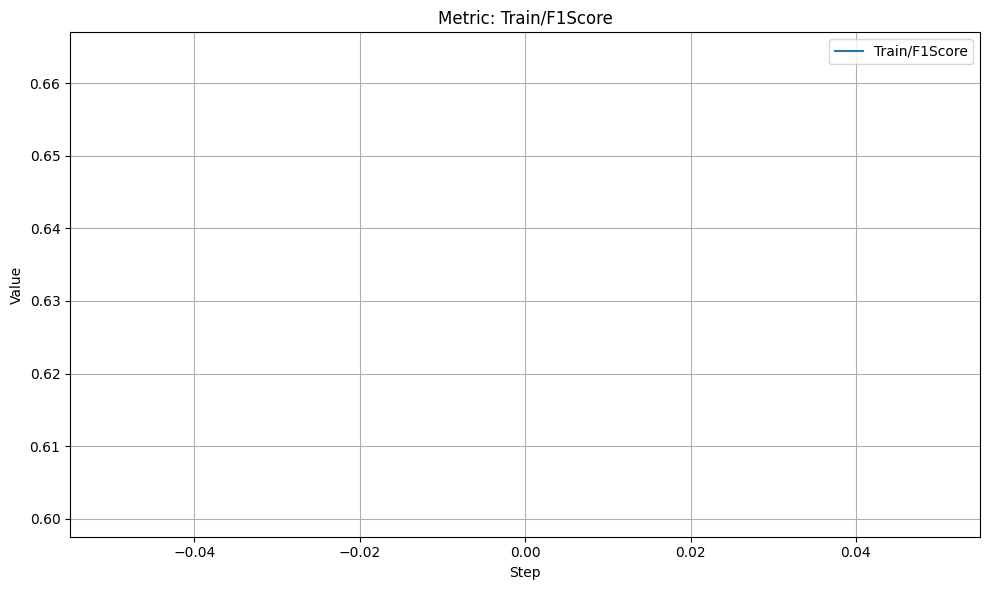

--- Finished processing. ---


In [31]:

# --- USAGE EXAMPLE ---
# Replace this with the actual path to your participant's folder.
# For example, based on your image, it might be:
# 'nebula_DFL_2025_10_14_19_55_23/metrics/participant_0'

path_to_data = 'app/logs/nebula_DFL_2025_10_14_19_55_23/metrics/participant_0' # <--- IMPORTANT: CHANGE THIS PATH

if not os.path.isdir(path_to_data):
        print("="*50)
        print(f"WARNING: The example path '{path_to_data}' does not exist.")
        print("Please update the 'path_to_data' variable in the script")
        print("to point to your actual data directory.")
        print("="*50)
else:
    plot_participant_metrics(path_to_data)
